# Import Library

In [1]:
import pandas as pd
import numpy as np
from scipy import linalg
from numpy import dot
import matplotlib.pyplot as plt
import warnings
import geopandas as gpd
import sys

sys.path.append('../src')
import functions as fct

warnings.filterwarnings('ignore')

## 1. Preprocessing the data

Loadign the fcd data (one day only)

In [2]:
#list all files within the fcd folder
BASEPATH = "../data/all_days/"
BASEPATHSIG = "../data/"
#TEST

In [3]:
fcd = pd.read_csv(BASEPATH + "2019-11-04.csv", names=['deviceID', 'lon', 'lat', 'speed', 'heading', 'datetime', "edge_id"])

In [4]:
fcd.head()

,deviceID,lon,lat,speed,heading,datetime,edge_id
0,960f7d4a61ebd37653b62ad01b73bc5fa674f17c,45.729567,4.894080,41,103,2019-11-04T00:00:00,1279718612
1,4fc30e93f60b7594b8765f1188a5a4213ba1665e,45.779620,4.894809,65,149,2019-11-04T00:00:00,1136736992
2,2fc34438e97f0fb03741fa88d311ed28d72aa835,45.764469,4.838434,57,1,2019-11-04T00:00:00,1229381640
3,960f7d4a61ebd37653b62ad01b73bc5fa674f17c,45.729549,4.894220,41,102,2019-11-04T00:00:01,1279718612
4,291a76a73f00d94d707a866c77888b6e89dec08d,45.723000,4.811923,48,-157,2019-11-04T00:00:01,1215341409


Converting the 'datetime' column to a datetime type, removing duplicate entries in the trip with the same datetime, and creating two new columns for the date and hour of each data point. Lastly, sort the data by ascending deviceID and datetime.

In [5]:
fcd['datetime'] = pd.to_datetime(fcd['datetime'])
fcd.drop_duplicates(subset=['deviceID', 'datetime'])
fcd['hour'] = fcd['datetime'].dt.hour
fcd['weekday'] = fcd['datetime'].dt.weekday
fcd.sort_values(by=["deviceID", "datetime"], inplace=True)

In [6]:
fcd.head()

,deviceID,lon,lat,speed,heading,datetime,edge_id,hour,weekday
843801,0001284ef0d63805efac7ee315d7150333eaea31,45.781770,4.935937,11,22,2019-11-04 17:51:02,58249807,17,0
844569,0001284ef0d63805efac7ee315d7150333eaea31,45.782035,4.940140,42,93,2019-11-04 17:51:33,809679006,17,0
845319,0001284ef0d63805efac7ee315d7150333eaea31,45.782010,4.941370,0,88,2019-11-04 17:52:02,809679005,17,0
846090,0001284ef0d63805efac7ee315d7150333eaea31,45.782000,4.942080,9,87,2019-11-04 17:52:33,809679005,17,0
846796,0001284ef0d63805efac7ee315d7150333eaea31,45.781990,4.942680,0,93,2019-11-04 17:53:02,58226941,17,0


We calculate the inter-event time between consecutive GPS points, the inter-event distance, and the corresponding speed. 
To compute the distance, we use the provided haversine function, which calculates the great-circle distance between two pairs of latitude and longitude coordinates. The shift function in pandas can be applied to align consecutive latitude–longitude points for this purpose. Special care should be taken when interpreting speed values at the start and end of each trip. In the following, we will rely on the speed column created here, rather than the one originally provided in the dataset.

In [7]:
def haversine(lat1, lon1, lat2, lon2):
    """
    slightly modified version: of http://stackoverflow.com/a/29546836/2901002
    Calculate the great circle distance between two points
    on the earth in km.
    All (lat, lon) coordinates must have numeric dtypes and be of equal length.
    """
    earth_radius=6371
    lat1, lon1, lat2, lon2 = np.radians([lat1, lon1, lat2, lon2])

    a = np.sin((lat2-lat1)/2.0)**2 + \
        np.cos(lat1) * np.cos(lat2) * np.sin((lon2-lon1)/2.0)**2
    return earth_radius * 2 * np.arcsin(np.sqrt(a))

In [8]:
# The original speed column in the dataset may be noisy or unreliable.
# We will recompute speed using forward differences between consecutive points within each device's trip.

# 1) Preserve any pre-existing speed for reference, and compute an enhanced one
#    - We keep the original as 'speed_orig'
#    - We will (re)compute 'speed' below using forward differences within each device
if "speed" in fcd.columns:
    fcd = fcd.rename(columns={"speed": "speed_orig"})

# 2) Pre-compute "next" point within each device to avoid crossing devices
lat_next  = fcd.groupby("deviceID")["lat"].shift(-1)
lon_next  = fcd.groupby("deviceID")["lon"].shift(-1)
time_next = fcd.groupby("deviceID")["datetime"].shift(-1)

# 3) Inter-event time (s): next - current, per device
fcd["diff_time"] = (time_next - fcd["datetime"]).dt.total_seconds()

# 4) Inter-event distance (m): haversine between current and next, per device
#    NOTE: If your haversine already returns meters, remove the "* 1000".
fcd["diff_dist"] = 1000 * haversine(lat_next, lon_next, fcd["lat"], fcd["lon"])

# 5) Recomputed speed (km/h): (m/s) * 3.6
#    - Last point per device has no "next" → NaN forward metrics (kept intentionally to preserve arrivals)
fcd["speed"] = 3.6 * fcd["diff_dist"] / fcd["diff_time"]

# 6) Guardrails:
#    - Remove nonsensical forward segments where diff_time <= 0 (duplicates/out-of-order timestamps)
#    - Keep rows (including arrivals); just null out invalid forward metrics
mask_nonpos_time = fcd["diff_time"] <= 0
fcd.loc[mask_nonpos_time, ["diff_time", "diff_dist", "speed"]] = np.nan

In [9]:
fcd[fcd["deviceID"]== '0001284ef0d63805efac7ee315d7150333eaea31']

,deviceID,lon,lat,speed_orig,heading,datetime,edge_id,hour,weekday,diff_time,diff_dist,speed
843801,0001284ef0d63805efac7ee315d7150333eaea31,45.781770,4.935937,11,22,2019-11-04 17:51:02,58249807,17,0,31.0,468.215235,54.373382
844569,0001284ef0d63805efac7ee315d7150333eaea31,45.782035,4.940140,42,93,2019-11-04 17:51:33,809679006,17,0,29.0,136.831489,16.985978
845319,0001284ef0d63805efac7ee315d7150333eaea31,45.782010,4.941370,0,88,2019-11-04 17:52:02,809679005,17,0,31.0,78.953724,9.168820
846090,0001284ef0d63805efac7ee315d7150333eaea31,45.782000,4.942080,9,87,2019-11-04 17:52:33,809679005,17,0,29.0,66.714368,8.281784
846796,0001284ef0d63805efac7ee315d7150333eaea31,45.781990,4.942680,0,93,2019-11-04 17:53:02,58226941,17,0,40.0,111.368038,10.023123
847807,0001284ef0d63805efac7ee315d7150333eaea31,45.781843,4.943671,10,123,2019-11-04 17:53:42,1215467824,17,0,31.0,147.465319,17.125005
848603,0001284ef0d63805efac7ee315d7150333eaea31,45.781207,4.944835,0,143,2019-11-04 17:54:13,1215464738,17,0,31.0,143.619518,16.678396
849358,0001284ef0d63805efac7ee315d7150333eaea31,45.780393,4.945841,17,139,2019-11-04 17:54:44,1215199180,17,0,4.0,20.912295,18.821066
849471,0001284ef0d63805efac7ee315d7150333eaea31,45.780210,4.945887,5,163,2019-11-04 17:54:48,62935075,17,0,6.0,28.167345,16.900407
849606,0001284ef0d63805efac7ee315d7150333eaea31,45.779983,4.946002,29,153,2019-11-04 17:54:54,62935075,17,0,19.0,76.578315,14.509576


Statistics of the dataset

In [10]:
len(fcd), len(fcd['deviceID'].unique()), fcd['diff_time'].mean()

(1043275, 42964, np.float64(37.0998362524656))

## 2. Speed profile analysis

Let's calculate the average speed profile by the hour and store it in a new dataframe named 'speed_profile.' 
The average speeds can be computed based on data from multiple days. 

In [11]:
temp = fcd.groupby(['edge_id', 'hour']).agg({"speed":['mean','count']})
temp.columns = ['mean_speed', 'mean_count']

In [12]:
temp

mean_speed  mean_count
edge_id    hour                        
58222058   13     47.318519           1
58222059   6       9.404282           1
           9      23.381785           1
           17     47.138879           1
58222088   9       0.170684           4
...                     ...         ...
1305711486 14     31.397521           1
           16     35.354559           1
1305714237 7      47.209571           1
           12     73.545263           1
1305743686 16      8.627065           3

[245258 rows x 2 columns]

Let's plot the speed profiles for the top 20 most popular edges.

In [13]:
fcd.head()

,deviceID,lon,lat,speed_orig,heading,datetime,edge_id,hour,weekday,diff_time,diff_dist,speed
843801,0001284ef0d63805efac7ee315d7150333eaea31,45.781770,4.935937,11,22,2019-11-04 17:51:02,58249807,17,0,31.0,468.215235,54.373382
844569,0001284ef0d63805efac7ee315d7150333eaea31,45.782035,4.940140,42,93,2019-11-04 17:51:33,809679006,17,0,29.0,136.831489,16.985978
845319,0001284ef0d63805efac7ee315d7150333eaea31,45.782010,4.941370,0,88,2019-11-04 17:52:02,809679005,17,0,31.0,78.953724,9.168820
846090,0001284ef0d63805efac7ee315d7150333eaea31,45.782000,4.942080,9,87,2019-11-04 17:52:33,809679005,17,0,29.0,66.714368,8.281784
846796,0001284ef0d63805efac7ee315d7150333eaea31,45.781990,4.942680,0,93,2019-11-04 17:53:02,58226941,17,0,40.0,111.368038,10.023123


In [14]:
speed_profile = temp['mean_speed'].unstack()
speed_profile

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
edge_id,,,,,,,,,,,,,,,,,,,,,
58222058,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
58222059,NaN,NaN,NaN,NaN,NaN,NaN,9.404282,NaN,NaN,23.381785,...,NaN,NaN,NaN,47.138879,NaN,NaN,NaN,NaN,NaN,NaN
58222088,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.170684,...,NaN,NaN,NaN,3.917202,NaN,NaN,NaN,NaN,NaN,NaN
58222089,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.386684,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
58222096,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.320387,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1305594489,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.193566,NaN,...,7.567099,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1305692274,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,13.883073,NaN,NaN,NaN,NaN
1305711486,NaN,NaN,NaN,NaN,NaN,NaN,39.496408,31.794887,34.827159,34.926161,...,31.397521,NaN,35.354559,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
fcd["edge_id"].value_counts()

edge_id
737545501     3733
783703777     3726
1215173586    2396
1036795723    2264
1230877722    2255
              ... 
831730122        1
920556450        1
920554589        1
920595577        1
920568984        1
Name: count, Length: 34115, dtype: int64

In [16]:
all_edges = list((fcd["edge_id"].value_counts()).index)

Text(0, 0.5, 'Speed(km/h)')

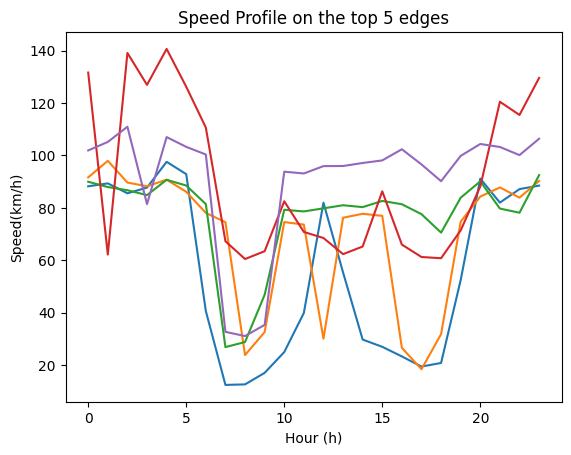

In [17]:
speed_profile[speed_profile.index.isin(all_edges[0:5])].T.plot(legend=False)
plt.title('Speed Profile on the top 5 edges')
plt.xlabel('Hour (h)')
plt.ylabel('Speed(km/h)')



Is the obtained matrix dense, or are there any missing values?  
Characterize the completeness of this matrix by calculating statistics on the number of missing data, the number of links with no missing data, and the average amount of missing data per edge.

In [18]:
speed_profile.isna().sum().sum() / (len(speed_profile) * 24) # proportion of missing values

np.float64(0.7112352826225024)

In [19]:
speed_profile.isna().sum(axis=1).mean() # average number of missing values per edge

np.float64(17.069646782940055)

## 3. Basic imputation

Create a new dataframe named 'sub_speed_profile' containing all edges from 'speed_profile' that have fewer than 12 missing values in their daily profiles.

In [20]:
sub_speed_profile = speed_profile[speed_profile.isna().sum(axis=1) <= 12]

Imputers are valuable tools for handling missing data in datasets. They help maintain data completeness, reduce bias, and ensure that important information is not lost during data analysis and modeling. By estimating missing values based on available data, imputers contribute to more reliable and informative results, benefiting various data-driven tasks, including machine learning and statistical analysis. 
In this section we will explore basic imputer to fill missing values.

Q3.2  
Implement an imputer using scikit-learn to fill in missing edge data profiles with the mean value of the profile. Utilize the 'SimpleImputer' object from scikit-learn (https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html).  
What other strategies could have been implemented for imputation?  
Plot some speed profiles to confirm that this operation has been executed correctly.

In [21]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')

In [22]:
'''
temp_speed_profile = (sub_speed_profile.T).copy(deep=True)
for i in temp_speed_profile.columns:
    temp_speed_profile[[i]] = imputer.fit_transform(temp_speed_profile[[i]])
sub_speed_profile_imputed = temp_speed_profile.T
'''

'\ntemp_speed_profile = (sub_speed_profile.T).copy(deep=True)\nfor i in temp_speed_profile.columns:\n    temp_speed_profile[[i]] = imputer.fit_transform(temp_speed_profile[[i]])\nsub_speed_profile_imputed = temp_speed_profile.T\n'

<Axes: xlabel='hour'>

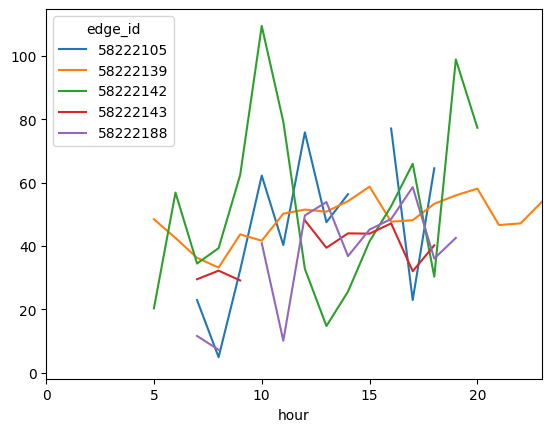

In [23]:
sub_speed_profile.iloc[0:5].T.plot(xlim=(0,23))

In [24]:
#sub_speed_profile_imputed.iloc[0:5].T.plot(xlim=(0,23))

In [25]:
#sub_speed_profile_imputed

## Spatial Mapping

We are now going to join the dataset with the information from the Lyon_Sig geopandas file

In [26]:
lyon_sig = gpd.read_file(BASEPATHSIG + "Lyon SIG/LyonSIG.shp")

In [27]:
lyon_sig

,AR_TAXIS,AR_TRUCKS,LINK_ID,AR_AUTO,DIR_TRAVEL,ST_NAME,PHYS_LANES,SPEED_CAT,AR_BUS,FUNC_CLASS,geometry
0,Y,N,58222010,Y,B,CHEMIN DU CREUX,2,7,Y,5,"LINESTRING (4.89822 45.82574, 4.89796 45.82584..."
1,Y,Y,58222028,Y,B,CHEMIN DU CREUX,2,6,Y,5,"LINESTRING (4.89839 45.82569, 4.89822 45.82574)"
2,Y,Y,58222036,Y,B,RUE DE LA BARSE,2,6,Y,5,"LINESTRING (4.89497 45.82547, 4.89476 45.82596..."
3,Y,Y,58222042,Y,B,RUE DE LA RÉPUBLIQUE,2,6,Y,4,"LINESTRING (4.87384 45.82575, 4.87387 45.82579..."
4,Y,Y,58222043,Y,F,RUE GAMBETTA,1,6,Y,5,"LINESTRING (4.87384 45.82575, 4.87368 45.82581..."
...,...,...,...,...,...,...,...,...,...,...,...
59639,Y,Y,1305711486,Y,B,ALLÉE DU GUÉ,2,7,Y,5,"LINESTRING (4.93339 45.80613, 4.93319 45.8063,..."
59640,Y,Y,1305714236,Y,B,CHEMIN DE FAMINE,2,6,Y,5,"LINESTRING (4.92831 45.82038, 4.92881 45.8205)"
59641,Y,Y,1305714237,Y,B,CHEMIN DE FAMINE,2,7,Y,5,"LINESTRING (4.92881 45.8205, 4.92919 45.8206, ..."
59642,Y,Y,1305743686,Y,B,RUE DES ROSES,2,6,Y,5,"LINESTRING (4.87738 45.72831, 4.87772 45.72859)"


In [28]:
import geopandas as gpd
import matplotlib.pyplot as plt
import imageio
import numpy as np
import os
import contextily as cx  # NEW

# Ensure output folder
out_dir = "../Output/map_frames"
os.makedirs(out_dir, exist_ok=True)

# Join profiles with Lyon network once
df_profiles = sub_speed_profile.copy()

# --- NEW: ensure both data and basemap share Web Mercator (EPSG:3857) ---
# If lyon_sig is not already in 4326, to_crs will handle it anyway.
lyon_sig_3857 = lyon_sig.to_crs(epsg=3857)

# Fix the animation extent once for all frames (prevents zoom/jitter)
minx, miny, maxx, maxy = lyon_sig_3857.total_bounds

# Choose colormap range once for consistency across frames
all_vals = df_profiles.values.flatten()
all_vals = all_vals[np.isfinite(all_vals)]
vmin, vmax = np.nanpercentile(all_vals, [5, 95])  # robust scaling

'''
frames = []
for hr in range (0,23):
    # Join hour profile
    col = f"speed_{hr:02d}"
    df_hr = df_profiles[[hr]].rename(columns={hr: col}).reset_index(names="edge_id")
    gdf = lyon_sig.merge(df_hr, left_on="LINK_ID", right_on="edge_id", how="left")

    # --- NEW: project joined GeoDataFrame to EPSG:3857 for basemap ---
    gdf_3857 = gdf.to_crs(epsg=3857)

    # Plot
    fig, ax = plt.subplots(figsize=(12, 12))
    gdf_3857.plot(
        column=col, cmap="Spectral", linewidth=1.2, ax=ax,
        vmin=vmin, vmax=vmax, legend=True, zorder=3
    )
    ax.set_title(f"Mean speed at {hr:02d}:00", fontsize=16)
    ax.set_xlim(minx, maxx)  # keep identical extent across frames
    ax.set_ylim(miny, maxy)
    ax.axis("off")

    # --- NEW: add a light basemap underneath ---
    # You can switch providers, e.g., cx.providers.CartoDB.Positron, Stamen.TonerLite, etc.
    cx.add_basemap(
        ax,
        source=cx.providers.CartoDB.DarkMatter,
        
        attribution_size=6
    )

    # Save frame
    frame_path = os.path.join(out_dir, f"frame_{hr:02d}.png")
    plt.savefig(frame_path, bbox_inches="tight", dpi=200)
    plt.close(fig)
    frames.append(imageio.imread(frame_path))

# Assemble into GIF (slower = larger duration)
#imageio.mimsave("../Output/speed_profiles.gif", frames, duration=50)
#print("Saved GIF as speed_profiles.gif")
'''


'\nframes = []\nfor hr in range (0,23):\n    # Join hour profile\n    col = f"speed_{hr:02d}"\n    df_hr = df_profiles[[hr]].rename(columns={hr: col}).reset_index(names="edge_id")\n    gdf = lyon_sig.merge(df_hr, left_on="LINK_ID", right_on="edge_id", how="left")\n\n    # --- NEW: project joined GeoDataFrame to EPSG:3857 for basemap ---\n    gdf_3857 = gdf.to_crs(epsg=3857)\n\n    # Plot\n    fig, ax = plt.subplots(figsize=(12, 12))\n    gdf_3857.plot(\n        column=col, cmap="Spectral", linewidth=1.2, ax=ax,\n        vmin=vmin, vmax=vmax, legend=True, zorder=3\n    )\n    ax.set_title(f"Mean speed at {hr:02d}:00", fontsize=16)\n    ax.set_xlim(minx, maxx)  # keep identical extent across frames\n    ax.set_ylim(miny, maxy)\n    ax.axis("off")\n\n    # --- NEW: add a light basemap underneath ---\n    # You can switch providers, e.g., cx.providers.CartoDB.Positron, Stamen.TonerLite, etc.\n    cx.add_basemap(\n        ax,\n        source=cx.providers.CartoDB.DarkMatter,\n\n        attri

In [29]:
fcd.columns

Index(['deviceID', 'lon', 'lat', 'speed_orig', 'heading', 'datetime',
       'edge_id', 'hour', 'weekday', 'diff_time', 'diff_dist', 'speed'],
      dtype='object')

In [30]:
fcd[fcd['deviceID']== '0001284ef0d63805efac7ee315d7150333eaea31'].iloc[0]


deviceID      0001284ef0d63805efac7ee315d7150333eaea31
lon                                           45.78177
lat                                           4.935937
speed_orig                                          11
heading                                             22
datetime                           2019-11-04 17:51:02
edge_id                                       58249807
hour                                                17
weekday                                              0
diff_time                                         31.0
diff_dist                                   468.215235
speed                                        54.373382
Name: 843801, dtype: object

## Create a df with only morning data

## Getting only origin and destination for each device

In [31]:
import functions as fct

In [32]:
df_od_neutral = fct.df_od(fcd)
df_od_neutral[(df_od_neutral['speed_first'] == 0) & (df_od_neutral['speed_last']==0)]


,deviceID,lon_first,lon_last,lat_first,lat_last,time_first,time_last,speed_first,speed_last,mean_speed,duration_min
405,02741815679c38f77d9b8784a8ed8a0c7fcf75a6,45.792600,45.820599,4.820800,4.848099,2019-11-04 18:23:40,2019-11-04 18:33:23,0,0,25.047619,9.716667
431,029b1e8b8c904e0cf0e77b82faa7e30345d1b3e1,45.735400,45.760730,4.842140,4.804460,2019-11-04 09:44:20,2019-11-04 10:20:04,0,0,21.131579,35.733333
892,05750e31e65ac8b890fec1eadf0e0f89d1ee4c41,45.785760,45.768544,4.807580,4.785328,2019-11-04 16:35:53,2019-11-04 16:43:07,0,0,23.583333,7.233333
910,05858be6c64537f46d5a09b41bdfc86630b2d4e9,45.765900,45.761509,4.897320,4.896679,2019-11-04 10:07:10,2019-11-04 10:29:13,0,0,27.260870,22.050000
1365,0857ca307f3f8996d7ef2c97a5db88949359fcbe,45.772099,45.772639,4.849902,4.856190,2019-11-04 08:28:44,2019-11-04 08:31:46,0,0,5.500000,3.033333
...,...,...,...,...,...,...,...,...,...,...,...
42280,fd86cf09ec9f6f17d0c938ab6195720f97322d2e,45.782620,45.785412,4.839351,4.829009,2019-11-04 14:47:24,2019-11-04 14:50:27,0,0,0.000000,3.050000
42316,fdbd518b19a76df9ac449b652afd97dd07d89b03,45.751039,45.751630,4.838504,4.840270,2019-11-04 11:48:18,2019-11-04 11:57:27,0,0,1.142857,9.150000
42668,ffd26b78c40350b7e059c99c8bc2bf4471141ff9,45.759361,45.716851,4.829781,4.854323,2019-11-04 15:33:26,2019-11-04 15:48:36,0,0,30.896552,15.166667
42672,ffd5c3104e5dda165c03fa5f0c30f42977aaf951,45.754710,45.757545,4.867522,4.842758,2019-11-04 14:33:40,2019-11-04 14:48:05,0,0,14.590909,14.416667


In [33]:


tempo = fcd.copy()

df_od = (
    tempo.groupby('deviceID')
    .agg({'lon': ['first', 'last'], 'lat': ['first', 'last']})
)

# Aplatir les colonnes multi-index
df_od.columns = ['lon_first', 'lon_last', 'lat_first', 'lat_last']
df_od = df_od.reset_index()

df_od.head()


,deviceID,lon_first,lon_last,lat_first,lat_last
0,0001284ef0d63805efac7ee315d7150333eaea31,45.781770,45.780492,4.935937,4.946468
1,00059766e64720cc53f01f1ac6aa8789bbe69a2e,45.813507,45.809910,4.935510,4.931160
2,0005df400cc6be4e3bbd127c90053708a03ffd84,45.702159,45.729420,4.835337,4.815340
3,0005e633f0de3898c3eb003dc279eb67011c9b32,45.693020,45.799421,4.844850,4.928322
4,0007992597ac40bf513f2d7a97cd4cdeb9b915ee,45.720285,45.687011,4.935293,4.846348


## Getting OD for trip longer than 15min

In [34]:
df_od['deviceID'].nunique() == df_od.shape[0]

True

## Plot the OD points 

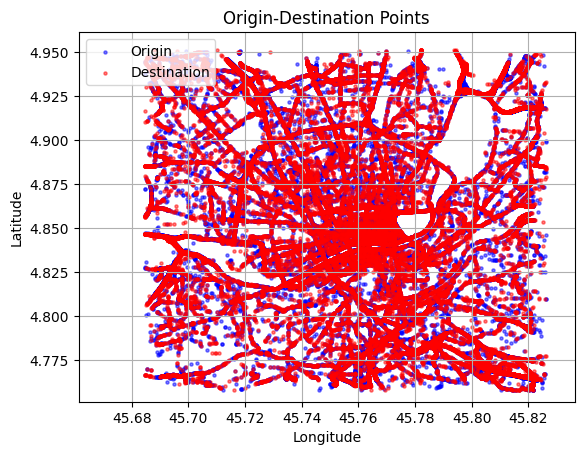

In [35]:
boundary_lon = max(max(df_od_neutral['lon_first']),max(df_od_neutral['lon_last'])) + 0.01
boundary_lat = max(max(df_od_neutral['lat_first']),max(df_od_neutral['lat_last'])) + 0.01




plt.scatter(df_od_neutral['lon_first'], df_od_neutral['lat_first'], color='blue', label='Origin', alpha=0.5, s=5)
plt.scatter(df_od_neutral['lon_last'], df_od_neutral['lat_last'], color='red', label='Destination', alpha=0.5, s=5)
plt.xlim(boundary_lon - 0.175, boundary_lon)  
plt.ylim(boundary_lat - 0.21, boundary_lat)  
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Origin-Destination Points')
plt.legend()
plt.grid(True)
plt.show()

Text(0, 0.5, 'Latitude')

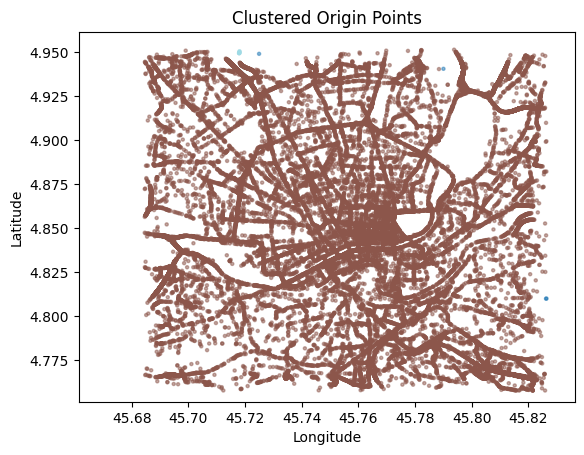

In [36]:
# Cluster the origin points using DBSCAN
df_temp = df_od.copy()
from sklearn.cluster import DBSCAN
origin_coords = df_temp[['lat_first', 'lon_first']].to_numpy()
dbscan = DBSCAN(eps=0.005, min_samples=7)  # eps is in degrees (~500m)
clusters = dbscan.fit_predict(origin_coords)
df_temp['origin_cluster'] = clusters
df_temp.head()
df_temp['origin_cluster'].value_counts()
#!/usr/bin/env python3
plt.scatter(df_temp['lon_first'], df_temp['lat_first'], c=df_temp['origin_cluster'], cmap='tab20', alpha=0.5, s=5)
plt.xlim(boundary_lon - 0.175, boundary_lon)
plt.ylim(boundary_lat - 0.21, boundary_lat)
plt.title('Clustered Origin Points')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

In [37]:
import folium
'''
# Point central sur Lyon
m = folium.Map(location=[45.75, 4.85], zoom_start=12, tiles='CartoDB positron')

# Ajouter les points départ-arrivée
for _, row in df_od.iterrows():
    # Point de départ
    folium.CircleMarker(
        location=[row['lon_first'], row['lat_first']],
        radius=3,
        color='green',
        fill=True,
        fill_opacity=0.7
    ).add_to(m)

    # Point d’arrivée
    folium.CircleMarker(
        location=[row['lon_last'], row['lat_last']],
        radius=3,
        color='red',
        fill=True,
        fill_opacity=0.7
    ).add_to(m)

    # # Tracer une ligne entre les deux
    # folium.PolyLine(
    #     locations=[
    #         [row['lat_first'], row['lon_first']],
    #         [row['lat_last'], row['lon_last']]
    #     ],
    #     color='blue',
    #     weight=1,
    #     opacity=0.4
    # ).add_to(m)

#m.save("carte_trajets.html")
m
'''

'\n# Point central sur Lyon\nm = folium.Map(location=[45.75, 4.85], zoom_start=12, tiles=\'CartoDB positron\')\n\n# Ajouter les points départ-arrivée\nfor _, row in df_od.iterrows():\n    # Point de départ\n    folium.CircleMarker(\n        location=[row[\'lon_first\'], row[\'lat_first\']],\n        radius=3,\n        color=\'green\',\n        fill=True,\n        fill_opacity=0.7\n    ).add_to(m)\n\n    # Point d’arrivée\n    folium.CircleMarker(\n        location=[row[\'lon_last\'], row[\'lat_last\']],\n        radius=3,\n        color=\'red\',\n        fill=True,\n        fill_opacity=0.7\n    ).add_to(m)\n\n    # # Tracer une ligne entre les deux\n    # folium.PolyLine(\n    #     locations=[\n    #         [row[\'lat_first\'], row[\'lon_first\']],\n    #         [row[\'lat_last\'], row[\'lon_last\']]\n    #     ],\n    #     color=\'blue\',\n    #     weight=1,\n    #     opacity=0.4\n    # ).add_to(m)\n\n#m.save("carte_trajets.html")\nm\n'

# Divide the area into iris

In [38]:
#découper Lyon en iris
lyon_iris = gpd.read_file(BASEPATHSIG + "Lyon IRIS/ter_territoire_teriris_latest.shp")
lyon_iris

,codeiris,libelle,type,typelibell,commune,insee,gid,geometry
0,690030000,Albigny-sur-SaÃ´ne,Z,Commune non irisÃ©e,Albigny-sur-SaÃ´ne,69003,1025,"POLYGON ((4.83686 45.86649, 4.83776 45.86532, ..."
1,690290101,Les GenÃªts-HÃ´pitaux,H,Habitat,Bron,69029,1026,"POLYGON ((4.89185 45.73853, 4.89188 45.7391, 4..."
2,690290102,Gendarmerie-Garenne,H,Habitat,Bron,69029,1027,"POLYGON ((4.90767 45.75106, 4.91091 45.75034, ..."
3,690290103,DubÅuf-Camille Rousset,H,Habitat,Bron,69029,1028,"POLYGON ((4.90512 45.73472, 4.9023 45.73567, 4..."
4,690290104,Ferdinand Buisson Ãglise,H,Habitat,Bron,69029,1029,"POLYGON ((4.91682 45.73677, 4.91423 45.7363, 4..."
...,...,...,...,...,...,...,...,...
507,691490602,Haute Roche Est,H,Habitat,Oullins,69149,1538,"POLYGON ((4.82531 45.69944, 4.82554 45.69944, ..."
508,691490603,Haute Roche Ouest,H,Habitat,Oullins,69149,1539,"POLYGON ((4.82835 45.70328, 4.82818 45.70324, ..."
509,691490604,Centre Pierre-BÃ©nite,H,Habitat,Oullins,69149,1540,"POLYGON ((4.8277 45.69287, 4.82536 45.69365, 4..."
510,691490605,Le Perron-Garanjou,H,Habitat,Oullins,69149,1541,"POLYGON ((4.82131 45.69766, 4.82031 45.69751, ..."


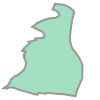

In [39]:
lyon_iris['geometry'].iloc[0]

<Axes: >

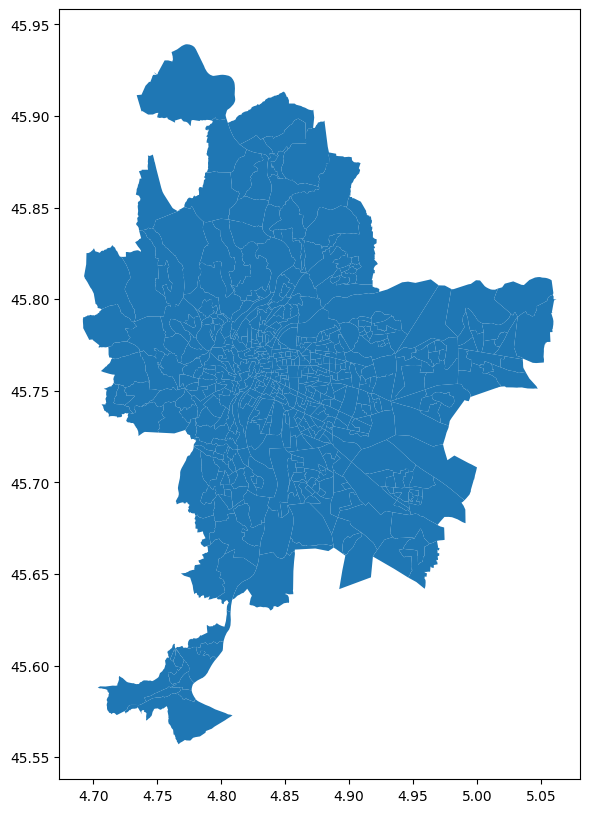

In [40]:
#afficher les iris de Lyon en surlignant la métropole 
lyon_iris.plot(figsize=(10,10))

In [41]:
#récupérer le df des origines et destinations 
df_od_neutral = fct.df_od(fcd)
df_od_neutral.head()

,deviceID,lon_first,lon_last,lat_first,lat_last,time_first,time_last,speed_first,speed_last,mean_speed,duration_min
0,0001284ef0d63805efac7ee315d7150333eaea31,45.781770,45.780492,4.935937,4.946468,2019-11-04 17:51:02,2019-11-04 17:55:13,11,36,14.454545,4.183333
1,00059766e64720cc53f01f1ac6aa8789bbe69a2e,45.813507,45.809910,4.935510,4.931160,2019-11-04 11:08:48,2019-11-04 11:09:19,26,52,39.000000,0.516667
2,0005df400cc6be4e3bbd127c90053708a03ffd84,45.702159,45.729420,4.835337,4.815340,2019-11-04 14:19:16,2019-11-04 14:22:12,88,26,46.000000,2.933333
3,0005e633f0de3898c3eb003dc279eb67011c9b32,45.693020,45.799421,4.844850,4.928322,2019-11-04 13:53:46,2019-11-04 14:05:05,88,108,86.884615,11.316667
4,0007992597ac40bf513f2d7a97cd4cdeb9b915ee,45.720285,45.687011,4.935293,4.846348,2019-11-04 11:07:12,2019-11-04 12:37:02,105,69,32.792793,89.833333


In [42]:
# faire une fonction qui détermine l'IRIS d'un point donné selon sa longitude et latitude

def get_iris_code(lon, lat):
    point = gpd.GeoDataFrame(
        geometry=[gpd.points_from_xy([lon], [lat])[0]],
        crs="EPSG:4326"
    )
    point_in_iris = gpd.sjoin(point, lyon_iris, how="left", predicate='within')
    if not point_in_iris.empty:
        return point_in_iris.iloc[0]["codeiris"]

    else:
        return None



# rajouter une colonne IRIS_origin et IRIS_destination à df_od_neutral, en utilisant les valeurs lon_first, lat_first et lon_last, lat_last et le shapefile lyon_iris
print(df_od_neutral.shape)
df_od_neutral['IRIS_origin'] = df_od_neutral.apply(lambda row: get_iris_code(row['lat_first'], row['lon_first']), axis=1)
df_od_neutral['IRIS_destination'] = df_od_neutral.apply(lambda row: get_iris_code(row['lat_last'], row['lon_last']), axis=1)

df_od_neutral.head()


(40984, 11)


,deviceID,lon_first,lon_last,lat_first,lat_last,time_first,time_last,speed_first,speed_last,mean_speed,duration_min,IRIS_origin,IRIS_destination
0,0001284ef0d63805efac7ee315d7150333eaea31,45.781770,45.780492,4.935937,4.946468,2019-11-04 17:51:02,2019-11-04 17:55:13,11,36,14.454545,4.183333,692560102.0,692750111.0
1,00059766e64720cc53f01f1ac6aa8789bbe69a2e,45.813507,45.809910,4.935510,4.931160,2019-11-04 11:08:48,2019-11-04 11:09:19,26,52,39.000000,0.516667,NaN,NaN
2,0005df400cc6be4e3bbd127c90053708a03ffd84,45.702159,45.729420,4.835337,4.815340,2019-11-04 14:19:16,2019-11-04 14:22:12,88,26,46.000000,2.933333,691490601.0,691420102.0
3,0005e633f0de3898c3eb003dc279eb67011c9b32,45.693020,45.799421,4.844850,4.928322,2019-11-04 13:53:46,2019-11-04 14:05:05,88,108,86.884615,11.316667,691990101.0,692560101.0
4,0007992597ac40bf513f2d7a97cd4cdeb9b915ee,45.720285,45.687011,4.935293,4.846348,2019-11-04 11:07:12,2019-11-04 12:37:02,105,69,32.792793,89.833333,692900702.0,691990402.0


<Axes: >

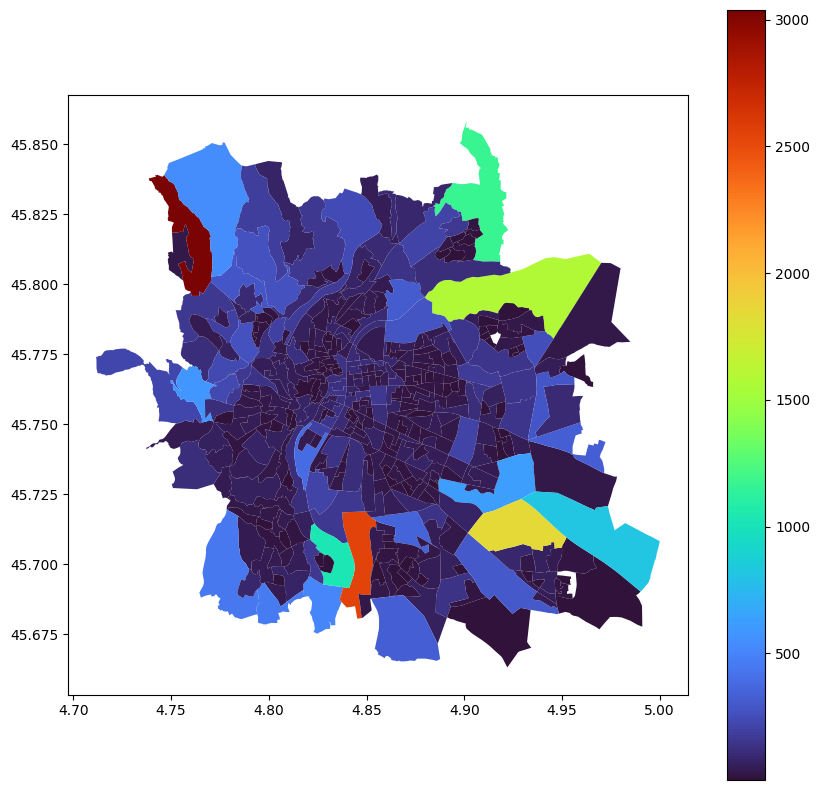

In [43]:
# introduire une colonne 'number of origins' à lyon_iris, qui compte le nombre de trajets partant de chaque iris
lyon_iris['number_of_origins'] = lyon_iris['codeiris'].map(
    df_od_neutral['IRIS_origin'].value_counts()
).fillna(0).astype(int)

# afficher les moyennes statistiques de la colonne 'number of origins' de lyon_iris
#lyon_iris['number_of_origins'].describe()

# supprimer les iris qui n'ont aucun trajet partant de leur territoire
lyon_iris_nonzero = lyon_iris[lyon_iris['number_of_origins'] > 0]

# plot la heatmap des iris de Lyon selon le nombre de trajets partant de chaque iris
lyon_iris_nonzero.plot(
    column="number_of_origins",
    cmap="turbo",
    legend=True,
    figsize=(10,10)
)

<Axes: >

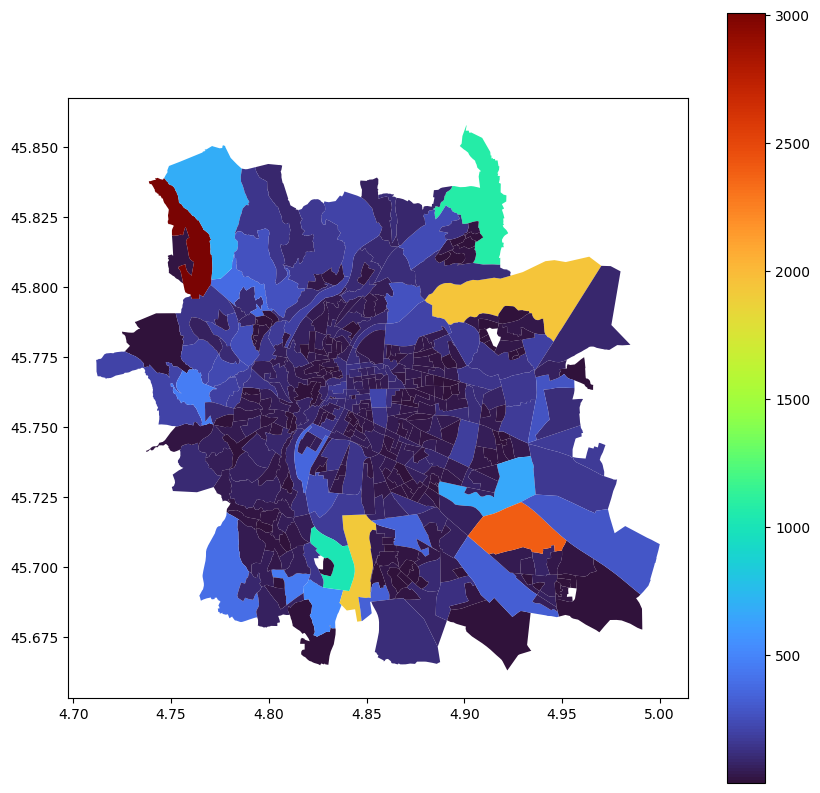

In [44]:
# pareil pour les destinations

# introduire une colonne 'number of destinations' à lyon_iris, qui compte le nombre de trajets arrivant à chaque iris
lyon_iris['number_of_destinations'] = lyon_iris['codeiris'].map(
    df_od_neutral['IRIS_destination'].value_counts()
).fillna(0).astype(int) 
lyon_iris['number_of_destinations'].describe()

# supprimer les iris qui n'ont aucun trajet arrivant à leur territoire
lyon_iris_nonzero_dest = lyon_iris[lyon_iris['number_of_destinations'] > 0]

# plot la heatmap des iris de Lyon selon le nombre de trajets arrivant à chaque iris
lyon_iris_nonzero_dest.plot(
    column="number_of_destinations",
    cmap="turbo",
    legend=True,
    figsize=(10,10)
)

In [45]:
# faire une matrice OD entre les iris
OD_iris = np.zeros((len(lyon_iris), len(lyon_iris)))

# nommer les lignes et colonnes avec les codes iris
iris_codes = lyon_iris['codeiris'].tolist()
OD_iris_df = pd.DataFrame(OD_iris, index=iris_codes, columns=iris_codes)

# remplir la matrice OD_iris_df avec en ligne les valeurs d'origine et en colonne les valeurs de destination
for _, row in df_od_neutral.iterrows():
    origin = row['IRIS_origin']
    destination = row['IRIS_destination']
    if origin in OD_iris_df.index and destination in OD_iris_df.columns:
        OD_iris_df.at[origin, destination] += 1

# fonction qui donne le nombre de trajets entre deux iris donnés
def get_od_count(iris_origin, iris_destination):
    if iris_origin in OD_iris_df.index and iris_destination in OD_iris_df.columns:
        return OD_iris_df.at[iris_origin, iris_destination]
    else:
        return 'bad iris code'

In [46]:
# afficher le nombre d'origines pour un iris donné
print(OD_iris_df.sum(axis=1).loc[df_od_neutral['IRIS_origin'].iloc[3]])
print(OD_iris_df.sum(axis=0).loc[df_od_neutral['IRIS_origin'].iloc[3]])

#comparer avec la valeur dans lyon_iris
print(lyon_iris.set_index('codeiris').at[df_od_neutral['IRIS_origin'].iloc[3], 'number_of_origins'])
print(lyon_iris.set_index('codeiris').at[df_od_neutral['IRIS_origin'].iloc[3], 'number_of_destinations'])



2438.0
1823.0
2544
1915
